# Hub Project Status Analysis Pipeline

**Objective**: Calculate weighted status progress for transit hubs based on intersecting projects

**Author**: Transport Modeling Team  
**Date**: January 2026  
**Pipeline**: Part 4 of Hub Prioritization System

## 1. Configuration

In [36]:
WD = r'/content/drive/MyDrive/Hubs_Urgency'
USE_PRE_EXPLODED = True

# Input files
FILTERED_CSV = WD + r'/Hubs_w_InventarProjects_filtered.csv'
HUBS_CSV = WD + r'/Hubs_w_InventarProjects_combined.csv'
PROJECT_DATA_CSV = WD + r'/Data/data.csv'
STATUS_WEIGHTS_CSV = WD + r'/Data/status_weights.csv'

# Optional: Status override file (columns: uid, Proj_status)
# If this file exists, it will update Proj_status for matching UIDs
STATUS_OVERRIDE_CSV = WD + r'/Data/status_override.csv'

# Output files
OUTPUT_PROGRESS_CSV = WD + r'/Hub_Status_Progress.csv'
OUTPUT_DETAILED_CSV = WD + r'/Hub_Project_Details.csv'

# Column configuration
GROUP_COL = 'group'
UID_COLUMNS = ['intersecting_points', 'intersecting_lines', 'intersecting_multilines']
ENCODING = 'windows-1255'

## 2. Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import os
from typing import List, Tuple, Optional
import ast

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)
pd.set_option('display.max_columns', 20)

## 3. Core Classes

In [38]:
class DataLoader:
    @staticmethod
    def load_csv(filepath: str, encoding: str = 'windows-1255') -> pd.DataFrame:
        try:
            df = pd.read_csv(filepath, encoding=encoding)
            logger.info(f"Loaded {filepath}: {len(df)} rows")
            return df
        except UnicodeDecodeError:
            df = pd.read_csv(filepath, encoding='utf-8-sig')
            logger.info(f"Loaded {filepath} with utf-8-sig: {len(df)} rows")
            return df

    @staticmethod
    def load_csv_if_exists(filepath: str, encoding: str = 'windows-1255') -> Optional[pd.DataFrame]:
        if os.path.exists(filepath):
            return DataLoader.load_csv(filepath, encoding)
        logger.info(f"File not found (skipping): {filepath}")
        return None

    @staticmethod
    def parse_list_column(df: pd.DataFrame, col: str) -> pd.DataFrame:
        if col not in df.columns:
            return df
        def parse_value(x):
            if isinstance(x, list): return x
            if pd.isna(x) or x == '' or x == '[]': return []
            try: return ast.literal_eval(str(x))
            except: return [i.strip().strip("'\"") for i in str(x).replace('[','').replace(']','').split(',') if i.strip()]
        result = df.copy()
        result[col] = result[col].apply(parse_value)
        return result

In [39]:
class StatusOverrideHandler:
    REQUIRED_COLS = ['uid', 'Proj_status']

    def __init__(self, override_df: Optional[pd.DataFrame] = None):
        self.override_df = None
        self.override_lookup = {}
        if override_df is not None:
            self._validate_and_prepare(override_df)

    def _validate_and_prepare(self, df: pd.DataFrame):
        missing = set(self.REQUIRED_COLS) - set(df.columns)
        if missing:
            raise ValueError(f"Status override file missing required columns: {missing}")
        self.override_df = df.copy()
        self.override_df['uid'] = pd.to_numeric(self.override_df['uid'], errors='coerce')
        self.override_df = self.override_df.dropna(subset=['uid', 'Proj_status'])
        self.override_lookup = dict(zip(self.override_df['uid'].astype(int), self.override_df['Proj_status']))
        logger.info(f"Loaded {len(self.override_lookup)} status overrides")

    def has_overrides(self) -> bool:
        return len(self.override_lookup) > 0

    def apply_overrides(self, df: pd.DataFrame, uid_col: str = 'project_uid', status_col: str = 'Proj_status') -> pd.DataFrame:
        if not self.has_overrides():
            logger.info("No status overrides to apply")
            return df
        result = df.copy()
        before_values = result[status_col].copy()
        def get_status(row):
            uid = row[uid_col]
            if pd.notna(uid):
                uid_int = int(uid)
                if uid_int in self.override_lookup:
                    return self.override_lookup[uid_int]
            return row[status_col]
        result[status_col] = result.apply(get_status, axis=1)
        changes = (before_values != result[status_col]).sum()
        logger.info(f"Applied {changes} status overrides")
        return result

In [ ]:
class StatusProgressCalculator:
    def __init__(self, status_weights_df: pd.DataFrame):
        self.weights_df = status_weights_df.copy()
        self.weight_lookup = dict(zip(self.weights_df['Proj_status'], self.weights_df['weight']))
        self.max_weight = self.weights_df['weight'].max()
        logger.info(f"Loaded {len(self.weight_lookup)} status weights (max={self.max_weight})")

    def get_weight(self, status) -> float:
        return self.weight_lookup.get(status, 0.0)

    def calculate_hub_progress(self, joined_df: pd.DataFrame, group_col: str = 'group', status_col: str = 'Proj_status') -> pd.DataFrame:
        df = joined_df.copy()
        df['status_weight'] = df[status_col].apply(self.get_weight)

        # Count only actual projects (not NaN placeholder rows for groups with 0 projects)
        if 'project_uid' in df.columns:
            df['_has_project'] = df['project_uid'].notna().astype(int)
        else:
            df['_has_project'] = 1

        progress = df.groupby(group_col).agg(
            total_projects=('_has_project', 'sum'),
            sum_weights=('status_weight', 'sum')
        ).reset_index()
        progress['max_possible'] = progress['total_projects'] * self.max_weight
        progress['status_progress'] = progress['sum_weights'] / progress['max_possible']
        progress['status_progress_pct'] = (progress['status_progress'] * 100).fillna(0).clip(0, 100)
        logger.info(f"Calculated progress for {len(progress)} hubs ({(progress['total_projects'] == 0).sum()} with 0 projects)")
        return progress

In [ ]:
class PreExplodedDataHandler:
    REQUIRED_COLS = ['group', 'project_uid', 'Proj_status']

    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        missing = set(self.REQUIRED_COLS) - set(self.df.columns)
        if missing: raise ValueError(f"Missing required columns: {missing}")
        self.df['project_uid'] = pd.to_numeric(self.df['project_uid'], errors='coerce')
        # Only drop rows where group is missing; keep rows with NaN project_uid
        # (these represent hub groups with 0 intersecting projects)
        self.df = self.df.dropna(subset=['group'])
        self.df = self.df.drop_duplicates(subset=['group', 'project_uid'])
        logger.info(f"Prepared {len(self.df)} rows ({self.df['project_uid'].notna().sum()} hub-project pairs, {self.df['project_uid'].isna().sum()} hub groups with 0 projects)")

    def get_data(self) -> pd.DataFrame:
        return self.df

In [ ]:
class RawDataHandler:
    def __init__(self, hub_df: pd.DataFrame, project_df: pd.DataFrame, uid_columns: List[str]):
        self.hub_df = hub_df.copy()
        self.project_df = project_df.copy()
        self.uid_columns = uid_columns

    def combine_and_explode(self, group_col: str = 'group') -> pd.DataFrame:
        df = self.hub_df.copy()
        for col in self.uid_columns:
            if col in df.columns: df = DataLoader.parse_list_column(df, col)
        def merge_uids(row):
            all_uids = set()
            for col in self.uid_columns:
                if col in row and isinstance(row[col], list): all_uids.update(row[col])
            return list(all_uids)
        df['all_project_uids'] = df.apply(merge_uids, axis=1)
        exploded = df.explode('all_project_uids').reset_index(drop=True)
        exploded = exploded.rename(columns={'all_project_uids': 'project_uid'})
        # Keep rows with NaN project_uid (hub groups with 0 intersecting projects)
        exploded['project_uid'] = pd.to_numeric(exploded['project_uid'], errors='coerce')
        self.project_df['uid'] = pd.to_numeric(self.project_df['uid'], errors='coerce')
        project_cols = ['uid', 'proj_name', 'main_type', 'Proj_status', 'scn_year']
        available_cols = [c for c in project_cols if c in self.project_df.columns]
        joined = exploded.merge(self.project_df[available_cols], left_on='project_uid', right_on='uid', how='left')
        joined = joined.drop_duplicates(subset=[group_col, 'project_uid'])
        n_with = joined['project_uid'].notna().sum()
        n_without = joined['project_uid'].isna().sum()
        logger.info(f"Created {len(joined)} rows from raw data ({n_with} hub-project pairs, {n_without} hub groups with 0 projects)")
        return joined

In [ ]:
class HubProjectStatusPipeline:
    def __init__(self, status_weights_df: pd.DataFrame, hub_project_df: Optional[pd.DataFrame] = None,
                 hub_df: Optional[pd.DataFrame] = None, project_df: Optional[pd.DataFrame] = None,
                 status_override_df: Optional[pd.DataFrame] = None, use_pre_exploded: bool = True,
                 all_hubs_df: Optional[pd.DataFrame] = None):
        self.calculator = StatusProgressCalculator(status_weights_df)
        self.override_handler = StatusOverrideHandler(status_override_df)
        self.use_pre_exploded = use_pre_exploded
        self.all_hubs_df = all_hubs_df
        if use_pre_exploded:
            self.handler = PreExplodedDataHandler(hub_project_df)
        else:
            self.hub_df = hub_df
            self.project_df = project_df

    def run(self, group_col: str = 'group', uid_columns: Optional[List[str]] = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
        logger.info(f"Running pipeline (Mode: {'Pre-exploded' if self.use_pre_exploded else 'Raw'})")

        # Step 1: Get joined data
        if self.use_pre_exploded:
            joined_df = self.handler.get_data()
        else:
            uid_cols = uid_columns or ['intersecting_points', 'intersecting_lines', 'intersecting_multilines']
            raw_handler = RawDataHandler(self.hub_df, self.project_df, uid_cols)
            joined_df = raw_handler.combine_and_explode(group_col)

        # Step 2: Apply status overrides if available
        if self.override_handler.has_overrides():
            joined_df = self.override_handler.apply_overrides(joined_df, uid_col='project_uid', status_col='Proj_status')

        # Step 3: Calculate progress
        progress_df = self.calculator.calculate_hub_progress(joined_df, group_col=group_col, status_col='Proj_status')

        # Step 4: Ensure all hub groups appear in progress (backfill missing ones with 0)
        if self.all_hubs_df is not None and group_col in self.all_hubs_df.columns:
            all_groups = self.all_hubs_df[[group_col]].drop_duplicates()
            n_before = len(progress_df)
            progress_df = all_groups.merge(progress_df, on=group_col, how='left')
            progress_df = progress_df.fillna({
                'total_projects': 0, 'sum_weights': 0,
                'max_possible': 0, 'status_progress': 0, 'status_progress_pct': 0
            })
            progress_df['total_projects'] = progress_df['total_projects'].astype(int)
            n_added = len(progress_df) - n_before
            if n_added > 0:
                logger.info(f"Added {n_added} hub groups with 0 projects (total: {len(progress_df)})")

        return joined_df, progress_df

## 4. Load Data

In [ ]:
loader = DataLoader()
weights_df = loader.load_csv(STATUS_WEIGHTS_CSV, encoding=ENCODING)
status_override_df = loader.load_csv_if_exists(STATUS_OVERRIDE_CSV, encoding=ENCODING)

# Always load the combined hubs CSV to get the full list of hub groups
all_hubs_df = loader.load_csv(HUBS_CSV, encoding=ENCODING)

if USE_PRE_EXPLODED:
    hub_project_df = loader.load_csv(FILTERED_CSV, encoding=ENCODING)
    hub_df, project_df = None, None
else:
    hub_df = all_hubs_df
    project_df = loader.load_csv(PROJECT_DATA_CSV, encoding=ENCODING)
    hub_project_df = None

In [45]:
print("Status Weights:")
display(weights_df)

Status Weights:


,Proj_status,Proj_status_id,weight
0,?,0,0.5
1,ייזום,1,0.7
2,תכנון אסטרטגי,2,1.0
3,תכנון מוקדם סטטוטורי,3,1.2
4,תכנון ראשוני,4,1.5
5,תכנון מוקדם,5,1.2
6,תכנון מפורט,6,1.0
7,ביצוע,7,0.7
8,הסתיים,8,0.5


In [46]:
if status_override_df is not None:
    print("STATUS OVERRIDE FILE LOADED")
    print(f"Total overrides: {len(status_override_df)}")
    print(f"\nOverride status distribution:")
    print(status_override_df['Proj_status'].value_counts())
    display(status_override_df.head())
else:
    print("No status override file found (using original status values)")

No status override file found (using original status values)


In [47]:
if USE_PRE_EXPLODED:
    print("Filtered Data Sample:")
    display(hub_project_df.head())
    print(f"\nUnique hubs: {hub_project_df['group'].nunique()}")
    print(f"Unique projects: {hub_project_df['project_uid'].nunique()}")
    if 'Proj_status' in hub_project_df.columns:
        print(f"\nOriginal Proj_status distribution:")
        print(hub_project_df['Proj_status'].value_counts())

Filtered Data Sample:


,group,x,y,HubNameHE,h3_index,intersecting_points,intersecting_lines,intersecting_multilines,project_uid,uid,proj_name,main_type,Proj_status,scn_year
0,528,35.108145,32.816776,אצטדיון קרית אתא,8a2db0a52227fff,[],"[7042, 200009]",[],200009,200009,מסילת זבולון,רכבת,?,2050
1,528,35.108145,32.816776,אצטדיון קרית אתא,8a2db0a52227fff,[],"[7042, 200009]",[],7042,7042,"רק""ל נופית","מתע""ן",ביצוע,2030
2,115,34.936611,32.220850,צומת רמת הכובש,8a2db018a967fff,[],[408004],[],408004,408004,LRT14 - BRT - קאלאנסווה - טירה - כפר סבא,"מתע""ן",תכנון ראשוני,2040
3,23,34.989450,32.240650,צומת צור נתן,8a2db00a5b67fff,[],"[20106, 408004]",[],408004,408004,LRT14 - BRT - קאלאנסווה - טירה - כפר סבא,"מתע""ן",תכנון ראשוני,2040
4,104,34.839784,32.214399,חנה וסע שפיים,8a2db018496ffff,[],"[32003, 200017, 408002, 408001]",[],200017,200017,מסילות 5 6 באיילון,רכבת,?,2050



Unique hubs: 113
Unique projects: 72

Original Proj_status distribution:
Proj_status
?                       111
תכנון מפורט             100
תכנון ראשוני             65
ביצוע                    23
תכנון אסטרטגי            19
תכנון מוקדם סטטוטורי      4
הסתיים                    1
Name: count, dtype: int64


## 5. Run Pipeline

In [ ]:
if USE_PRE_EXPLODED:
    pipeline = HubProjectStatusPipeline(
        status_weights_df=weights_df,
        hub_project_df=hub_project_df,
        status_override_df=status_override_df,
        use_pre_exploded=True,
        all_hubs_df=all_hubs_df
    )
else:
    pipeline = HubProjectStatusPipeline(
        status_weights_df=weights_df,
        hub_df=hub_df,
        project_df=project_df,
        status_override_df=status_override_df,
        use_pre_exploded=False,
        all_hubs_df=all_hubs_df
    )

joined_df, progress_df = pipeline.run(
    group_col=GROUP_COL,
    uid_columns=UID_COLUMNS if not USE_PRE_EXPLODED else None
)

In [49]:
print(f"Hub-Project Pairs: {len(joined_df):,}")
print(f"Hubs with Progress: {len(progress_df):,}")
print(f"Unique Projects: {joined_df['project_uid'].nunique():,}")

if status_override_df is not None:
    print(f"\nProj_status distribution AFTER overrides:")
    print(joined_df['Proj_status'].value_counts())

Hub-Project Pairs: 223
Hubs with Progress: 113
Unique Projects: 72


## 6. Results

In [50]:
print(f"Progress Statistics:")
print(f"  Mean: {progress_df['status_progress_pct'].mean():.2f}%")
print(f"  Median: {progress_df['status_progress_pct'].median():.2f}%")
print(f"  Min: {progress_df['status_progress_pct'].min():.2f}%")
print(f"  Max: {progress_df['status_progress_pct'].max():.2f}%")

Progress Statistics:
  Mean: 65.00%
  Median: 66.67%
  Min: 33.33%
  Max: 100.00%


In [51]:
display(progress_df.head(10))

,group,total_projects,sum_weights,max_possible,status_progress,status_progress_pct
0,2,1,1.5,1.5,1.000000,100.000000
1,3,1,1.5,1.5,1.000000,100.000000
2,6,1,1.5,1.5,1.000000,100.000000
3,10,1,1.5,1.5,1.000000,100.000000
4,12,1,1.5,1.5,1.000000,100.000000
5,14,2,1.0,3.0,0.333333,33.333333
6,22,1,1.5,1.5,1.000000,100.000000
7,23,1,1.5,1.5,1.000000,100.000000
8,27,3,2.5,4.5,0.555556,55.555556
9,29,3,4.0,4.5,0.888889,88.888889


## 7. Visualizations

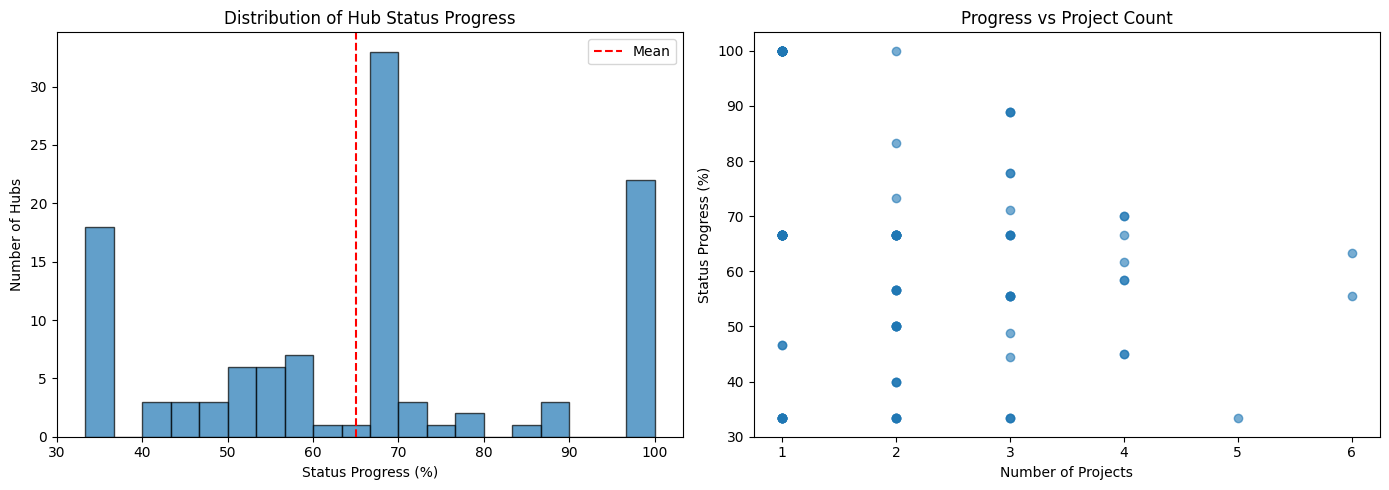

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(progress_df['status_progress_pct'], bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(progress_df['status_progress_pct'].mean(), color='red', linestyle='--', label='Mean')
axes[0].set_xlabel('Status Progress (%)')
axes[0].set_ylabel('Number of Hubs')
axes[0].set_title('Distribution of Hub Status Progress')
axes[0].legend()
axes[1].scatter(progress_df['total_projects'], progress_df['status_progress_pct'], alpha=0.6)
axes[1].set_xlabel('Number of Projects')
axes[1].set_ylabel('Status Progress (%)')
axes[1].set_title('Progress vs Project Count')
plt.tight_layout()
plt.show()

## 8. Export

In [53]:
progress_df.to_csv(OUTPUT_PROGRESS_CSV, index=False, encoding=ENCODING)
print(f"Saved: {OUTPUT_PROGRESS_CSV}")

export_cols = [c for c in joined_df.columns if c != 'h3_polygon_geom']
joined_df[export_cols].to_csv(OUTPUT_DETAILED_CSV, index=False, encoding=ENCODING)
print(f"Saved: {OUTPUT_DETAILED_CSV}")

Saved: /content/drive/MyDrive/Hubs_Urgency/Hub_Status_Progress.csv
Saved: /content/drive/MyDrive/Hubs_Urgency/Hub_Project_Details.csv


---
## Status Override File Format

To update project statuses, create a CSV file at `Data/status_override.csv` with columns:

| uid | Proj_status |
|-----|-------------|
| 123 | new_status |
| 456 | new_status |

The pipeline will automatically detect the file and update matching UIDs.